In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
class DummyPop:
    def __init__(self, label, colour):
        self.label = label
        self.colour = colour

In [ ]:
reload(helpers)
parts = 34

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5/qcflag-5", parts, label="Static potential", colour="black"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/time-evolving-pot/time-evolving-pot", parts, label="Evolving potential", colour="tab:purple"),
]
kinematics = helpers.get_kinematics(pops)
bin_nums = helpers.get_shaped_bin_nums(pops)

mass = {}
for pop in pops:
    masses = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))
    mass[pop.label] = masses

helpers.save_postprocessed_data(
    pops, ["/mnt/ceph/users/twagg/underworld/postprocessed/qcflag-5", "/mnt/ceph/users/twagg/underworld/postprocessed/time-evolving-pot"],
    kinematics, mass, bin_nums
)

In [4]:
pops = [DummyPop("Static potential", "black"), DummyPop("Evolving potential", "tab:purple")]
data = helpers.load_postprocessed_data(
    ["/mnt/ceph/users/twagg/underworld/postprocessed/qcflag-5", "/mnt/ceph/users/twagg/underworld/postprocessed/time-evolving-pot"],
    ["Static potential", "Evolving potential"]
)

In [5]:
print("Escaped fractions:")
for pop in pops:
    escaped = data[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {data[pop.label]["escaped"]["CO"].sum() / len(data[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {data[pop.label]["escaped"]["NS"].sum() / len(data[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Static potential:
      - CO = 0.106
      - BH = 0.029
      - NS = 0.136
  - Evolving potential:
      - CO = 0.191
      - BH = 0.065
      - NS = 0.240


Inner 10 kpc
  Static potential fraction within 0.5 kpc 0.49
  Evolving potential fraction within 0.5 kpc 0.25
Full population
  Static potential fraction within 0.5 kpc 0.39
  Evolving potential fraction within 0.5 kpc 0.16


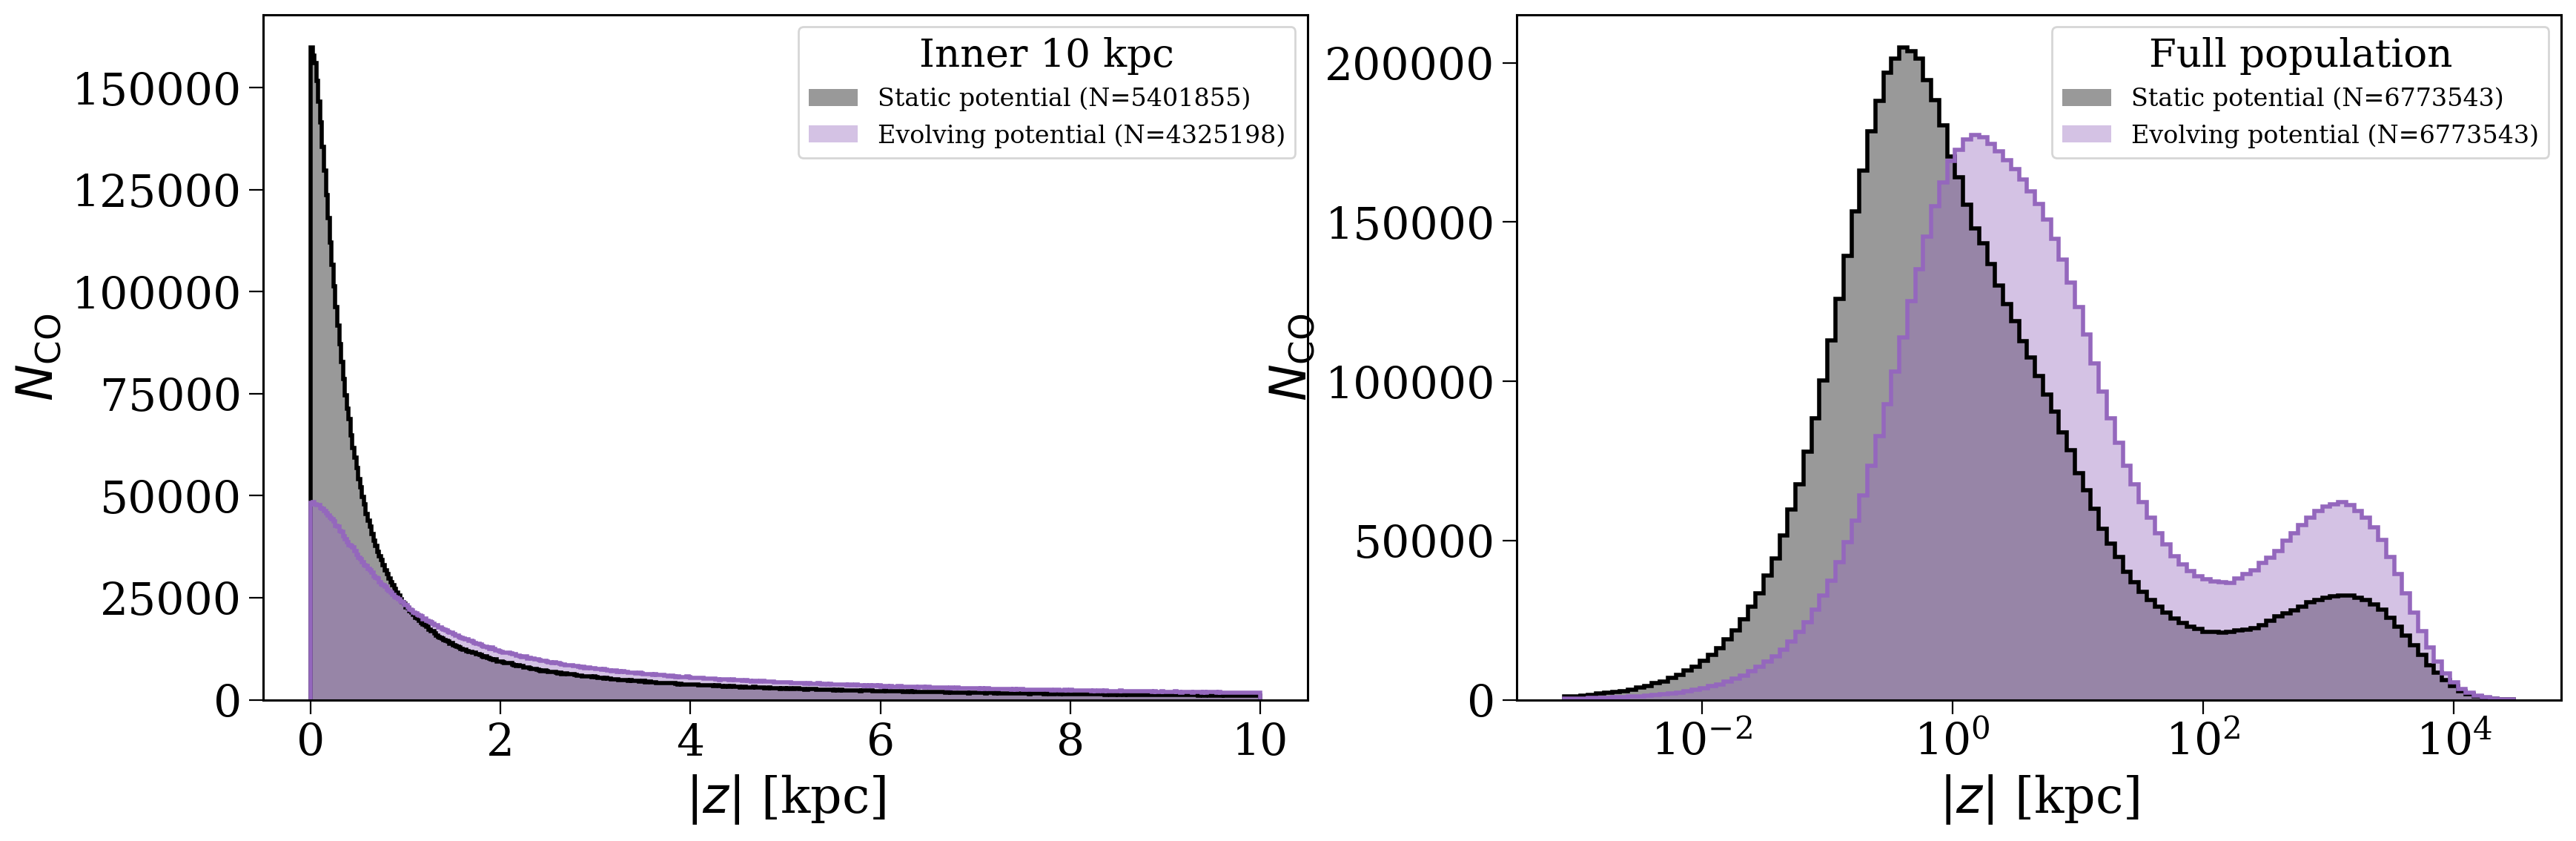

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [8]:
reload(plotting)
plotting.absolute_galactocentric_height(pops, data)

[ 2.24343308  7.81450392 15.06637873 16.97731672]
[1.6954089  8.0270242  5.87323335 8.28024743]


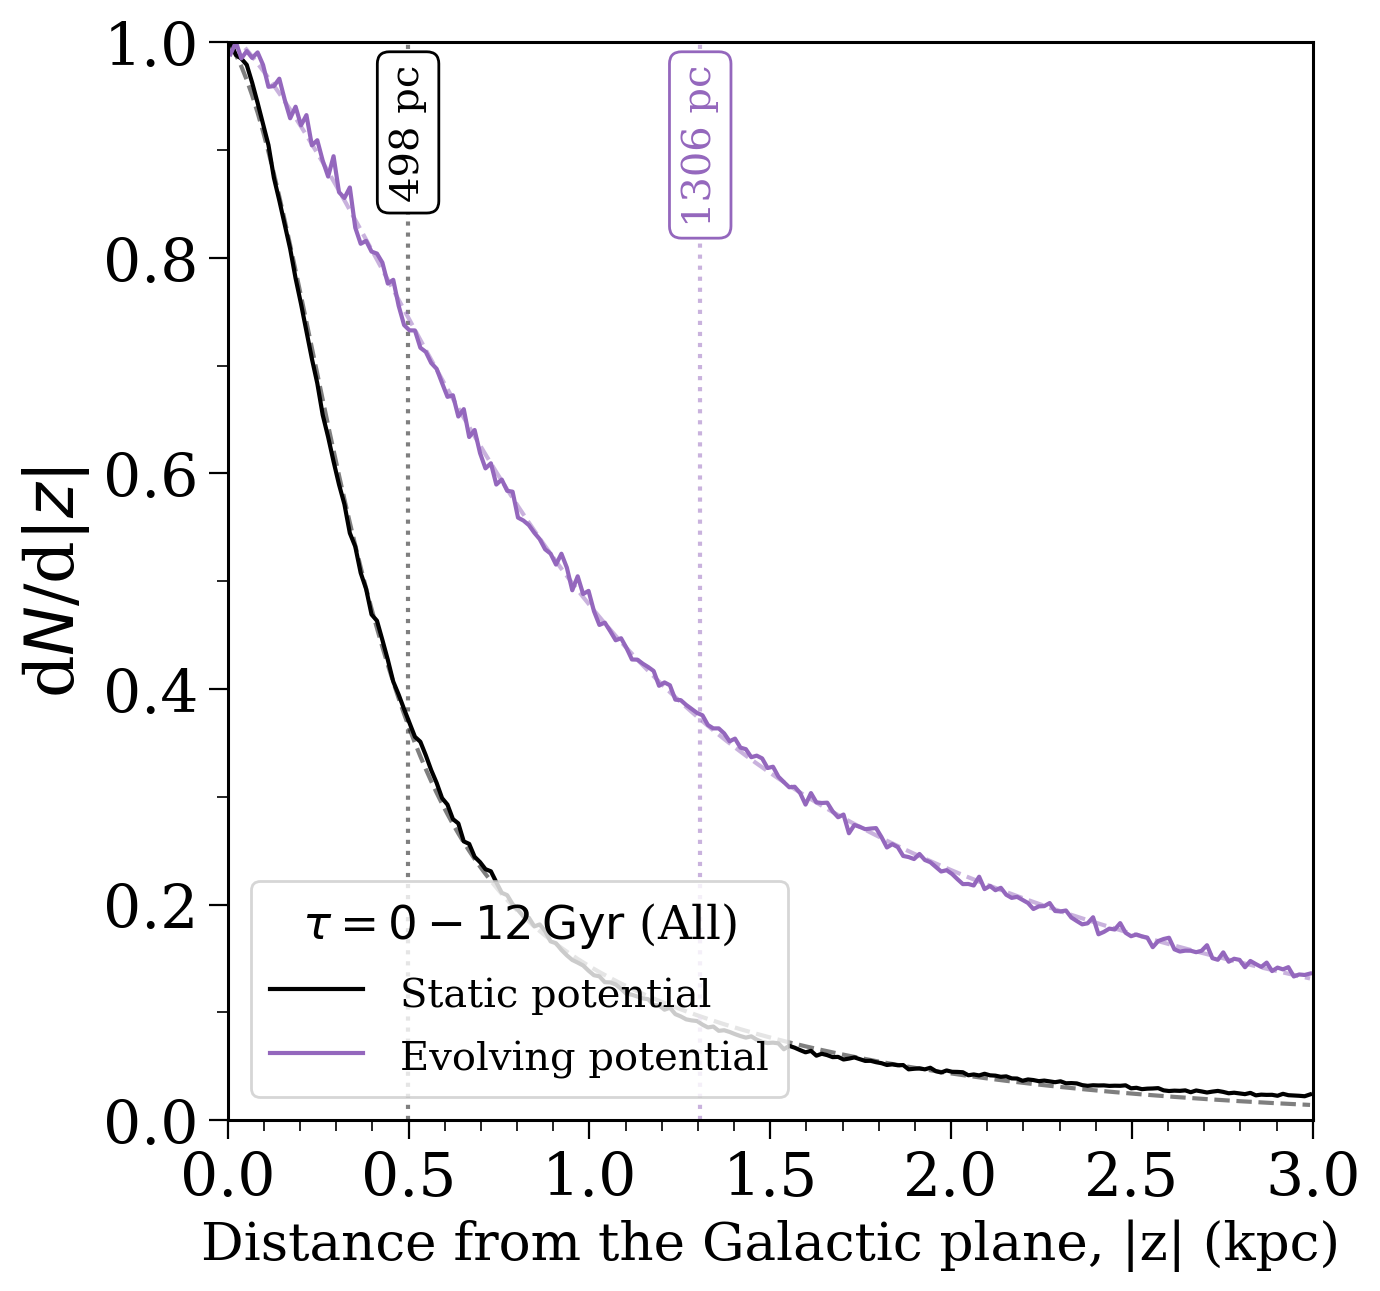

[ 2.16932095  9.08402777 10.12860272 13.86414703]
[ 3.32270334 19.32174066 11.68807598  9.20214676]


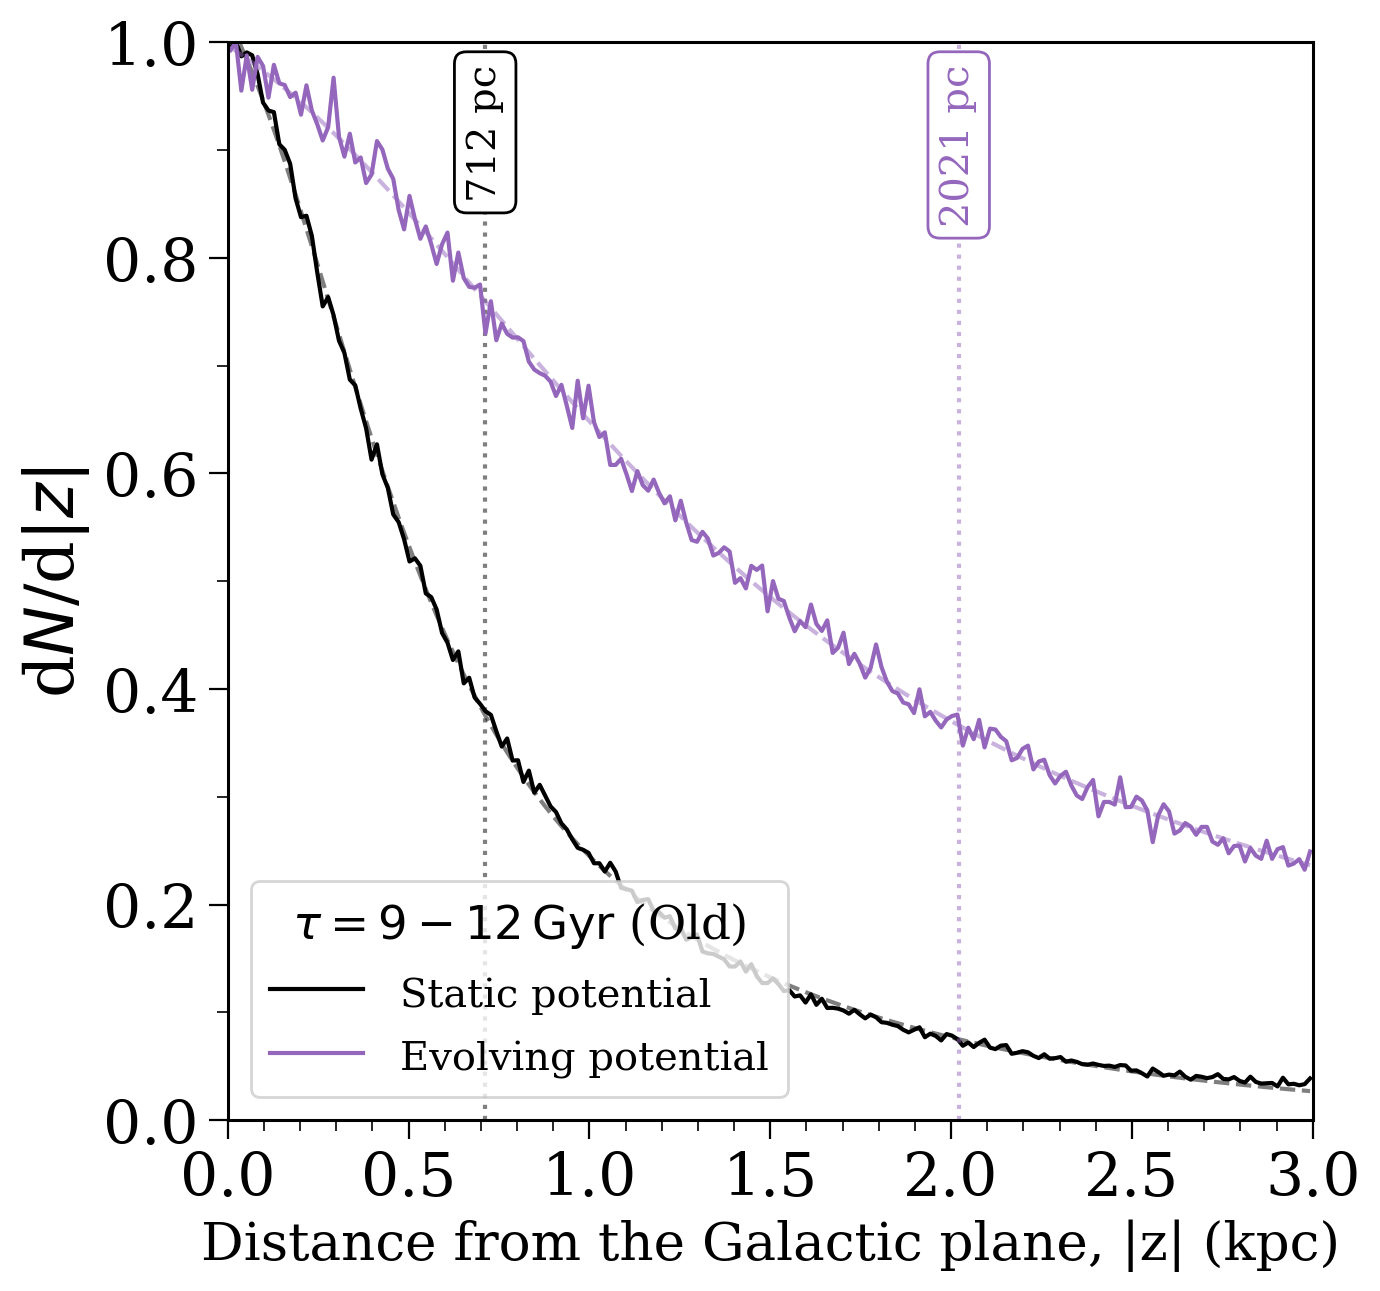

[ 2.59402621  8.73653468 23.39215759 18.13246843]
[1.95245872 9.00355221 7.43389046 8.78039587]


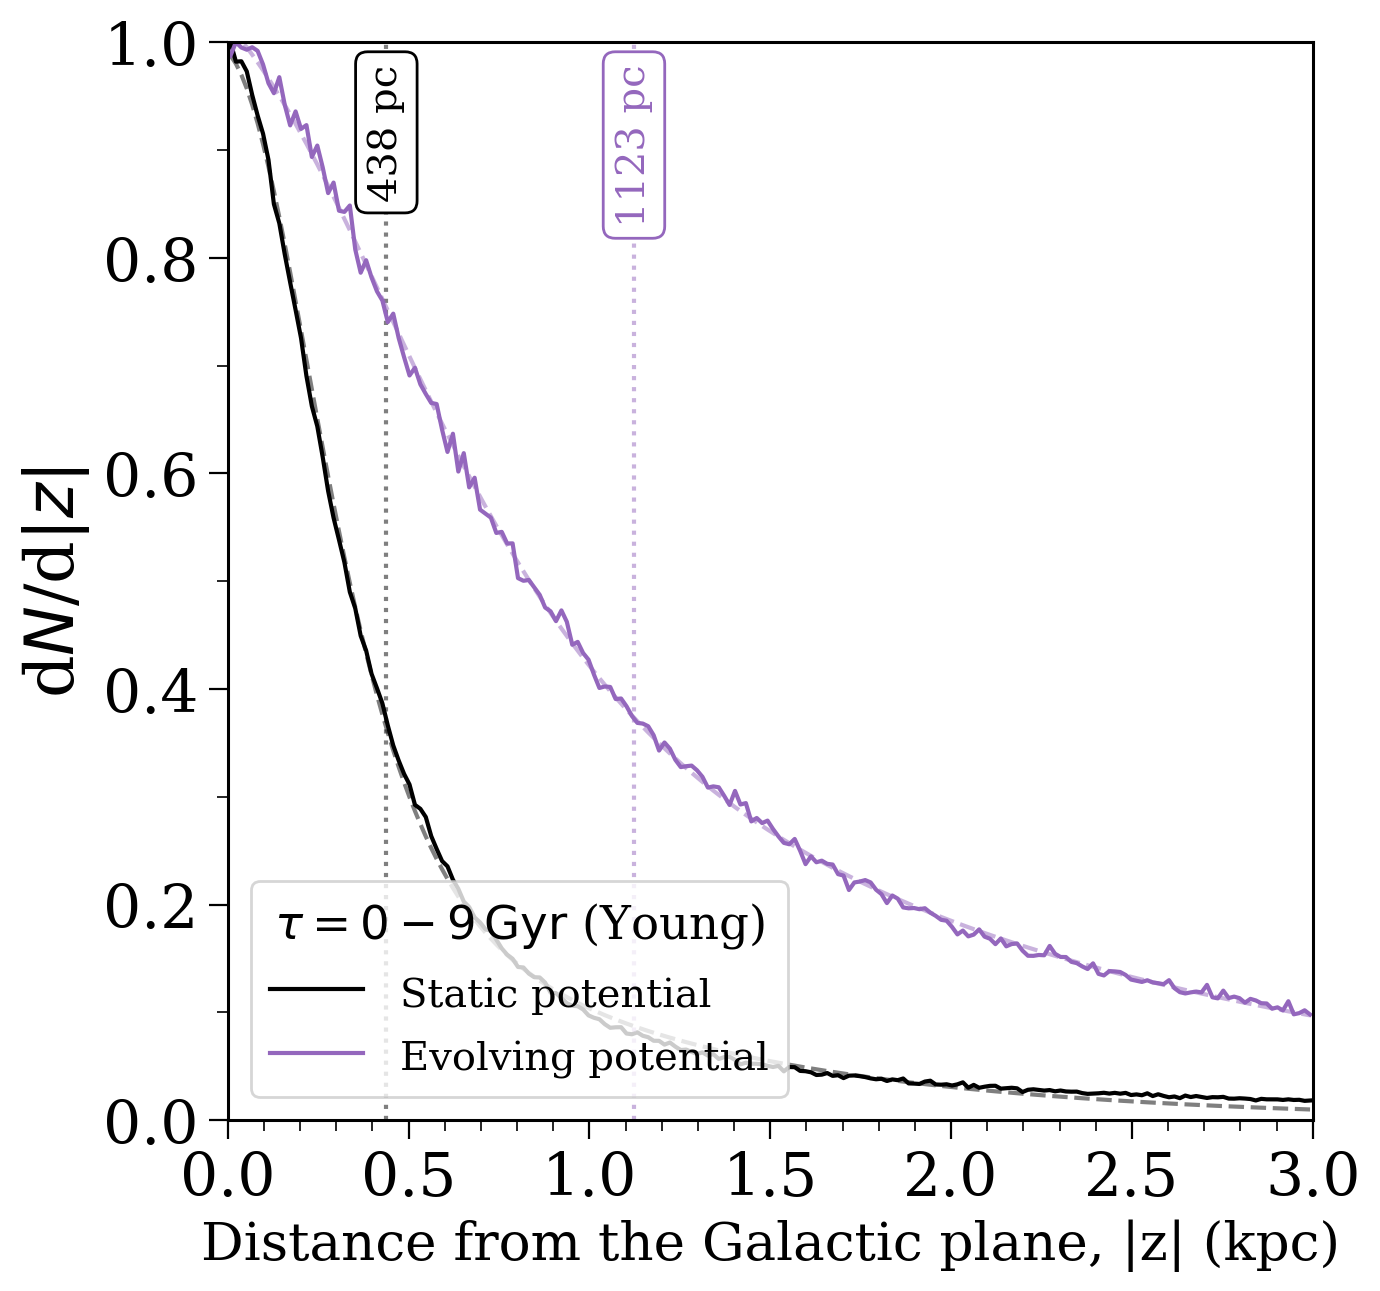

In [9]:
reload(plotting)

for tau_min, tau_max, tau_label in zip([0, 9, 0], [12, 12, 9], ["All", "Old", "Young"]):
    fig, ax = plt.subplots(figsize=(7, 7))
    for pop in pops:
        tau = data[pop.label]["tau"]["BH"]
        mask = (tau > tau_min) & (tau <= tau_max)
        scale_height, _, _ = plotting.estimate_scale_height(
            z=data[pop.label]["pos"]["BH"][:, 2][mask],
            plot=True,
            label=pop.label,
            colour=pop.colour,
            show=False,
            fig=fig,
            ax=ax,
            bins=np.linspace(0, 3, 201),
            xlim=(0, 3),
            ylim=(0, 1),
            n_components=2,
            scale_height_locs=[0.98, 0.98],
            R=None,
        )

    leg = ax.get_legend()
    for text in leg.get_texts():
        text.set_fontsize(0.6 * fs)
    leg.set_title(f"$\\tau = {tau_min} - {tau_max} \\, \\mathrm{{Gyr}}$ ({tau_label})", prop={'size': 0.7 * fs})
    leg.set_loc("lower left")

    # add minor ticks every 0.1 kpc
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

    # plt.savefig("../plots/scale_height_time_evolving.pdf", format="pdf", bbox_inches='tight')
    plt.show()

In [123]:
z_range = np.geomspace(0.1, 10, 1000)
mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2])
            for pop in pops] + [np.abs(data[pops[0].label]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

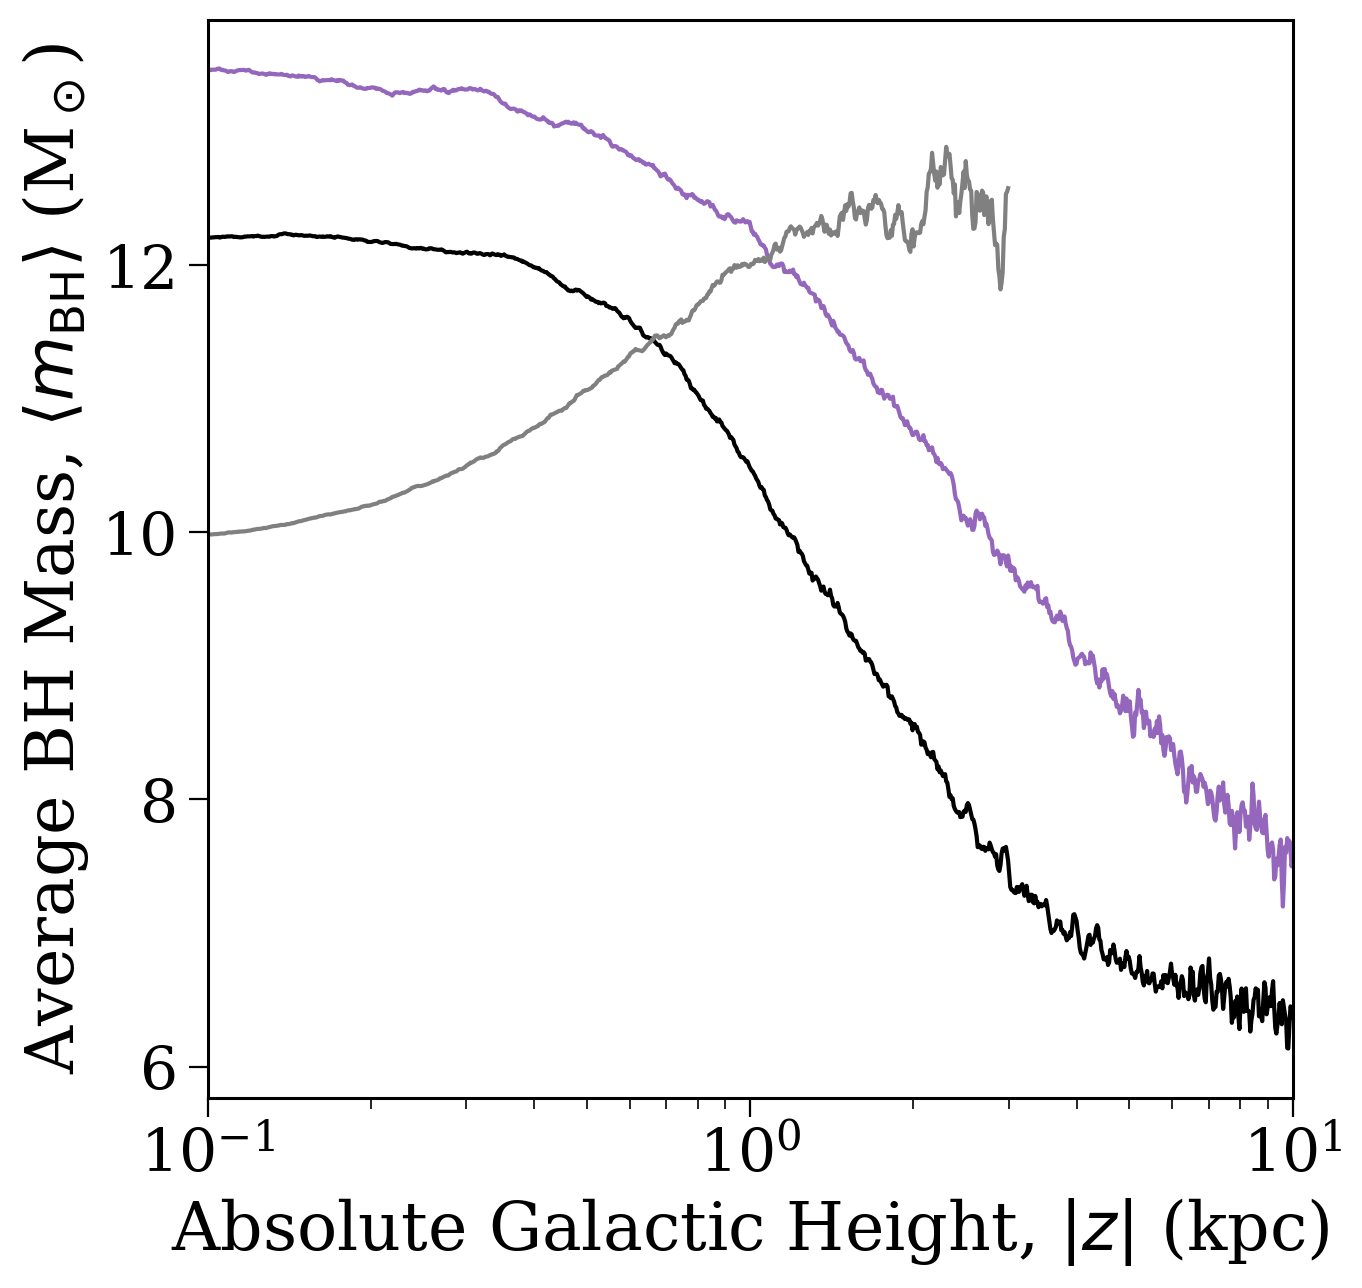

In [125]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="grey")

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average BH Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

plt.show()